# Cantilever beam data generation with OpenSeesPy

This notebook creates a 2D Euler-Bernoulli cantilever with 30 beam elements, simulates sinusoidal loading, a double ship-impact loading, and free vibration, then saves the selected responses to a pickle file.

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import openseespy.opensees as ops
from scipy.integrate import solve_ivp

In [48]:
# Beam and discretization parameters
n_elements = 30
n_nodes = n_elements + 1
length = 30.0
element_length = length / n_elements
width = 0.30
height = 0.50
area = width * height
inertia = width * height**3 / 12.0
youngs_modulus = 210.0e9
density = 7850.0
mass_per_length = density * area
gravity = 9.81
zeta = 0.02

dt = 0.002
t_end = 20.0
time = np.arange(0.0, t_end + dt, dt)
n_steps = len(time)

# The model has 3 DOFs per node: horizontal displacement, vertical displacement, rotation.
force_node = n_nodes
force_dof = 3 * (force_node - 1) + 1
selected_nodes = [force_node]
selected_direction = 2
selected_dofs = np.array([3 * (node - 1) + selected_direction - 1 for node in selected_nodes], dtype=int)

print(f"Elements: {n_elements}, nodes: {n_nodes}")
print(f"Beam properties: A={area:.4f} m^2, I={inertia:.6e} m^4")
print(f"Selected OpenSees DOF: {force_dof}")

Elements: 30, nodes: 31
Beam properties: A=0.1500 m^2, I=3.125000e-03 m^4
Selected OpenSees DOF: 91


In [50]:
def build_model(n_modes=3):
    ops.wipe()
    ops.model("basic", "-ndm", 2, "-ndf", 3)

    for node in range(1, n_nodes + 1):
        x = (node - 1) * element_length
        ops.node(node, x, 0.0)
        if node == 1:
            ops.fix(node, 1, 1, 1)
        else:
            nodal_mass = mass_per_length * element_length / 2.0
            ops.mass(node, nodal_mass, nodal_mass, 1.0e-6)

    ops.geomTransf("Linear", 1)
    for element in range(1, n_elements + 1):
        ops.element("elasticBeamColumn", element, element, element + 1, area, youngs_modulus, inertia, 1)

    eigenvalues = np.asarray(ops.eigen(n_modes), dtype=float)
    natural_omega = np.sqrt(eigenvalues)
    rayleigh_alpha = 2.0 * zeta * natural_omega[0] * natural_omega[1] / (natural_omega[0] + natural_omega[1])
    rayleigh_beta = 2.0 * zeta / (natural_omega[0] + natural_omega[1])
    ops.rayleigh(rayleigh_alpha, 0.0, 0.0, rayleigh_beta)
    return natural_omega, rayleigh_alpha, rayleigh_beta


natural_omega, rayleigh_alpha, rayleigh_beta = build_model()

# --- Extract M and K directly from OpenSees instead of hand-assembling ---
ops.wipeAnalysis()
ops.system('FullGeneral')
ops.analysis('Transient')

# Mass matrix
ops.integrator('GimmeMCK', 1.0, 0.0, 0.0)
ops.analyze(1, 0.0)
N = ops.systemSize()          # <-- moved here, after analyze()
M = np.array(ops.printA('-ret')).reshape(N, N)

# Stiffness matrix
ops.integrator('GimmeMCK', 0.0, 0.0, 0.0, 1.0)
ops.analyze(1, 0.0)
K = np.array(ops.printA('-ret')).reshape(N, N)

C = rayleigh_alpha * M + rayleigh_beta * K

WARNING analysis Transient - no Algorithm yet specified, 
 NewtonRaphson default will be used
WARNING analysis Transient - no ConstraintHandler yet specified, 
 PlainHandler default will be used
WARNING analysis Transient - no Numberer specified, 
 RCM default will be used
WARNING analysis Transient - no Integrator specified, 
 TransientIntegrator default will be used


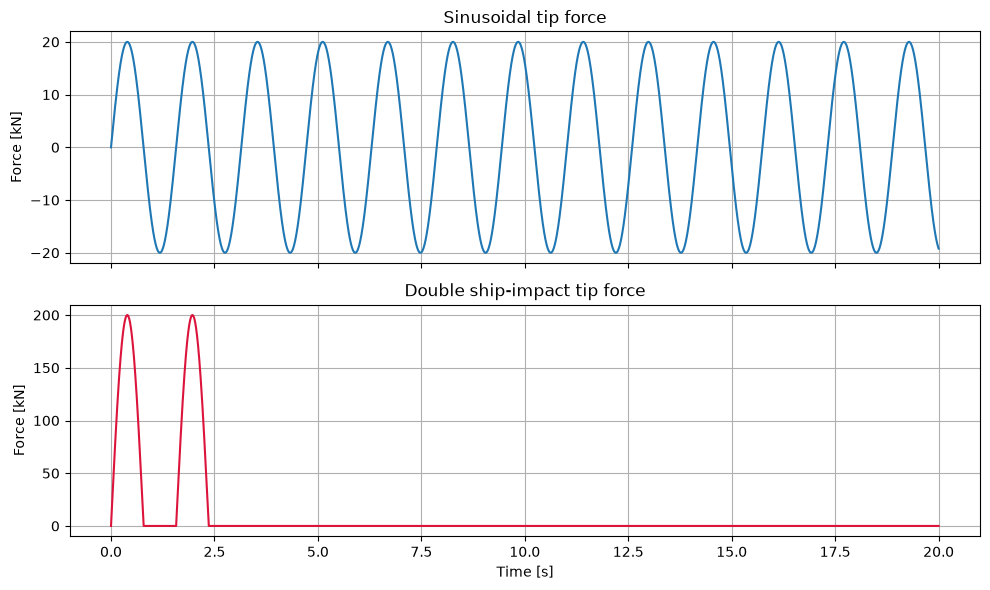

In [51]:
# Force histories

F0 = 2.0e4
p_sine = F0 * np.sin(natural_omega[0] * time)

impact_amplitude = 10.0 * F0
impact_period = 2.0 * np.pi / natural_omega[0]
p_ship = np.zeros_like(time)
mask_1 = (time >= 0.0) & (time <= 0.5 * impact_period)
mask_2 = (time >= impact_period) & (time <= 1.5 * impact_period)
p_ship[mask_1] = impact_amplitude * np.sin(np.pi * time[mask_1] / (0.5 * impact_period))
p_ship[mask_2] = impact_amplitude * np.sin(np.pi * (time[mask_2] - impact_period) / (0.5 * impact_period))

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(time, p_sine / 1e3)
axes[0].set_ylabel("Force [kN]")
axes[0].set_title("Sinusoidal tip force")
axes[0].grid(True)
axes[1].plot(time, p_ship / 1e3, color="crimson")
axes[1].set_ylabel("Force [kN]")
axes[1].set_xlabel("Time [s]")
axes[1].set_title("Double ship-impact tip force")
axes[1].grid(True)
plt.tight_layout()
plt.show()

In [52]:
def transient_response(force_history):
    build_model()
    ops.timeSeries("Path", 1, "-dt", dt, "-values", *force_history.tolist())
    ops.pattern("Plain", 1, 1)
    ops.load(force_node, 0.0, 1.0, 0.0)
    ops.constraints("Transformation")
    ops.numberer("RCM")
    ops.system("BandGeneral")
    ops.test("NormDispIncr", 1.0e-8, 20)
    ops.algorithm("Linear")
    ops.integrator("Newmark", 0.5, 0.25)
    ops.analysis("Transient")

    response = np.zeros((2 * len(selected_dofs), n_steps))
    for step in range(n_steps):
        if step > 0 and ops.analyze(1, dt) != 0:
            raise RuntimeError(f"Transient analysis failed at step {step}")
        for i, node in enumerate(selected_nodes):
            response[i, step] = ops.nodeDisp(node, selected_direction)
            response[len(selected_dofs) + i, step] = ops.nodeVel(node, selected_direction)
    ops.wipe()
    return response


def free_vibration_response():
    build_model()
    ops.timeSeries("Constant", 2)
    ops.pattern("Plain", 2, 2)
    ops.load(force_node, 0.0, F0, 0.0)
    ops.constraints("Transformation")
    ops.numberer("RCM")
    ops.system("BandGeneral")
    ops.test("NormDispIncr", 1.0e-8, 30)
    ops.algorithm("Linear")
    ops.integrator("LoadControl", 1.0)
    ops.analysis("Static")
    if ops.analyze(1) != 0:
        raise RuntimeError("Static preload analysis failed")
    ops.loadConst("-time", 0.0)
    ops.remove("loadPattern", 2)

    ops.wipeAnalysis()
    ops.test("NormDispIncr", 1.0e-8, 20)
    ops.algorithm("Linear")
    ops.integrator("Newmark", 0.5, 0.25)
    ops.analysis("Transient")
    response = np.zeros((2 * len(selected_dofs), n_steps))
    for step in range(n_steps):
        if step > 0 and ops.analyze(1, dt) != 0:
            raise RuntimeError(f"Free-vibration analysis failed at step {step}")
        for i, node in enumerate(selected_nodes):
            response[i, step] = ops.nodeDisp(node, selected_direction)
            response[len(selected_dofs) + i, step] = ops.nodeVel(node, selected_direction)
    ops.wipe()
    return response


z_sine = transient_response(p_sine)
z_ship = transient_response(p_ship)
z_free = free_vibration_response()

WARNING analysis Transient - no ConstraintHandler yet specified, 
 PlainHandler default will be used
WARNING analysis Transient - no Numberer specified, 
 RCM default will be used
WARNING analysis Transient - no LinearSOE specified, 
 ProfileSPDLinSOE default will be used


In [ ]:
# =============================================================================
# Modal analytical benchmark (single eigen solve, no repeated ops.eigen calls)
# =============================================================================
n_modes_check = 10


def modal_analysis(n_modes):
    natural_omega_local, _, _ = build_model(n_modes=n_modes)
    output_node = selected_nodes[0]
    phi_out = np.array(
        [ops.nodeEigenvector(output_node, mode + 1, selected_direction) for mode in range(n_modes)]
    )
    phi_force = np.array(
        [ops.nodeEigenvector(force_node, mode + 1, selected_direction) for mode in range(n_modes)]
    )
    ops.wipe()
    return natural_omega_local, phi_out, phi_force


omegas, phi_out, phi_force = modal_analysis(n_modes_check)
zetas = 0.5 * (rayleigh_alpha / omegas + rayleigh_beta * omegas)
omega_d = omegas * np.sqrt(1.0 - zetas**2)

# --- Free vibration: exact closed form, released from static deflection under F0 ---
q0 = (phi_force * F0) / omegas**2
z_free_analytical = np.zeros_like(time)
v_free_analytical = np.zeros_like(time)
for mode in range(n_modes_check):
    decay = np.exp(-zetas[mode] * omegas[mode] * time)
    z_free_analytical += phi_out[mode] * q0[mode] * decay * (
        np.cos(omega_d[mode] * time)
        + (zetas[mode] * omegas[mode] / omega_d[mode]) * np.sin(omega_d[mode] * time)
    )
    v_free_analytical += (
        -phi_out[mode]
        * q0[mode]
        * decay
        * (omegas[mode] ** 2 / omega_d[mode])
        * np.sin(omega_d[mode] * time)
    )

# --- Sine forcing: exact closed form (steady-state + transient matched to zero ICs) ---
w = natural_omega[0]
z_sine_analytical = np.zeros_like(time)
v_sine_analytical = np.zeros_like(time)
for mode in range(n_modes_check):
    wn, zn, wdn = omegas[mode], zetas[mode], omega_d[mode]
    modal_force = phi_force[mode] * F0
    denom = np.sqrt((wn**2 - w**2) ** 2 + (2 * zn * wn * w) ** 2)
    Xp = modal_force / denom
    phase = np.arctan2(2 * zn * wn * w, wn**2 - w**2)
    qp0 = -Xp * np.sin(phase)
    qp_dot0 = Xp * w * np.cos(phase)
    A = -qp0
    B = (zn * wn * A - qp_dot0) / wdn
    transient = np.exp(-zn * wn * time)
    q_n = Xp * np.sin(w * time - phase) + transient * (
        A * np.cos(wdn * time) + B * np.sin(wdn * time)
    )
    q_n_dot = Xp * w * np.cos(w * time - phase) + transient * (
        (-zn * wn * A + wdn * B) * np.cos(wdn * time)
        + (-zn * wn * B - wdn * A) * np.sin(wdn * time)
    )
    z_sine_analytical += phi_out[mode] * q_n
    v_sine_analytical += phi_out[mode] * q_n_dot

# --- Ship impact: no closed form (piecewise pulse) — high-accuracy modal ODE solve ---
z_ship_analytical = np.zeros_like(time)
v_ship_analytical = np.zeros_like(time)
for mode in range(n_modes_check):
    wn, zn = omegas[mode], zetas[mode]
    modal_force_history = phi_force[mode] * p_ship

    def rhs(t, y, wn=wn, zn=zn, force_history=modal_force_history):
        q, qd = y
        force = np.interp(t, time, force_history)
        return [qd, force - 2 * zn * wn * qd - wn**2 * q]

    solution = solve_ivp(
        rhs,
        (time[0], time[-1]),
        [0.0, 0.0],
        t_eval=time,
        method="RK45",
        rtol=1e-9,
        atol=1e-12,
    )
    z_ship_analytical += phi_out[mode] * solution.y[0]
    v_ship_analytical += phi_out[mode] * solution.y[1]

# =============================================================================
# Plots — one figure per load case
# =============================================================================
def plot_case(title, z_fe, z_ana, v_ana):
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axes[0].plot(time, z_fe[0], label="FE")
    axes[0].plot(time, z_ana, "--", label="Analytical")
    axes[0].set_ylabel("Tip displacement [m]")
    axes[0].set_title(title)
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(time, z_fe[1], label="FE")
    axes[1].plot(time, v_ana, "--", label="Analytical")
    axes[1].set_ylabel("Tip velocity [m/s]")
    axes[1].set_xlabel("Time [s]")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_case("Sinusoidal tip force", z_sine, z_sine_analytical, v_sine_analytical)
plot_case("Double ship-impact tip force", z_ship, z_ship_analytical, v_ship_analytical)
plot_case("Free vibration", z_free, z_free_analytical, v_free_analytical)

NameError: name 'selected_node' is not defined

In [ ]:
# Save state-space responses for later use
import pickle

state_space_responses = {
    "time": time,
    "sinusoidal_force": p_sine,
    "ship_impact_force": p_ship,
    "z_sine": z_sine,
    "z_ship": z_ship,
    "z_free": z_free,
    "selected_dofs": selected_dofs,
    "selected_nodes": selected_nodes,
    "selected_direction": selected_direction,
    "force_node": force_node,
    "force_dof": force_dof,
    "dt": dt,
    "M": M,
    "K": K,
    "C": C,
}

pickle_path = "data_cantilever.pkl"
with open(pickle_path, "wb") as pickle_file:
    pickle.dump(state_space_responses, pickle_file, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved state-space responses to {pickle_path}")

Saved state-space responses to data_cantilever.pkl


: 

: 